# scurvy walkthrough

This notebook shows a minimal `scanpy` workflow together with the current `scurvy` plotting helpers.

It is meant to demonstrate the library as it exists today:

- categorical and continuous UMAP plotting
- categorical color overrides
- split UMAP panels
- count and proportion summaries

Assumptions used throughout:

- UMAP coordinates are stored in `adata.obsm["X_umap"]`
- categorical plots use `adata.obs` columns with categorical dtype
- display renaming can be provided through `adata.uns["rename_dict"]`

In [ ]:
import scanpy as sc
import scuva as scv

SEED = 7

In [2]:
adata = sc.read_10x_mtx("../test/data/pbmc3k/hg19")

In [3]:
# For a quick example, no QC (read counts, % mitochondrial, etc.) is performed.
# In a real dataset QC should always be performed.
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=10_000)
sc.pp.log1p(adata)

/var/folders/2s/_00dd2vx0blcvkt9x4m4l1th0000gn/T/ipykernel_1461/3424156113.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, svd_solver="arpack", random_state=SEED, use_highly_variable=True)


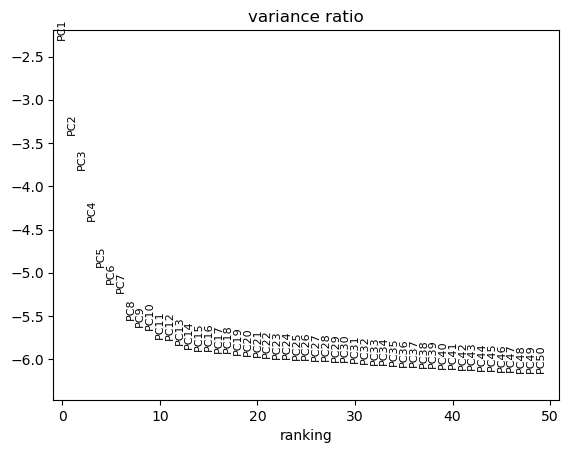

In [4]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000, layer="counts")
sc.tl.pca(adata, svd_solver="arpack", random_state=SEED, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

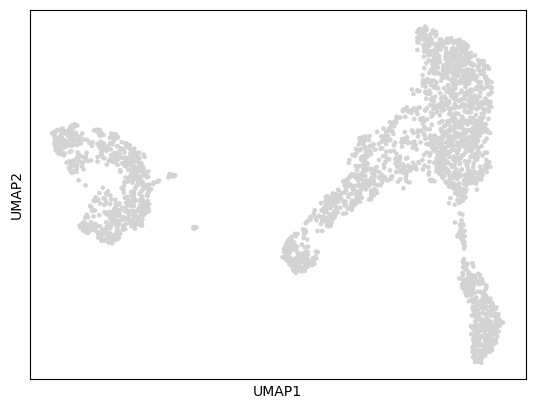

In [5]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=8, use_rep="X_pca",
                method='umap', metric='euclidean', random_state=SEED)
sc.tl.umap(adata, min_dist=0.2, spread=1.0, random_state=SEED)
sc.pl.umap(adata)

## UMAP plotting

After computing a UMAP embedding and a clustering, `scurvy.umap` can draw either a side legend or labels directly on the embedding.

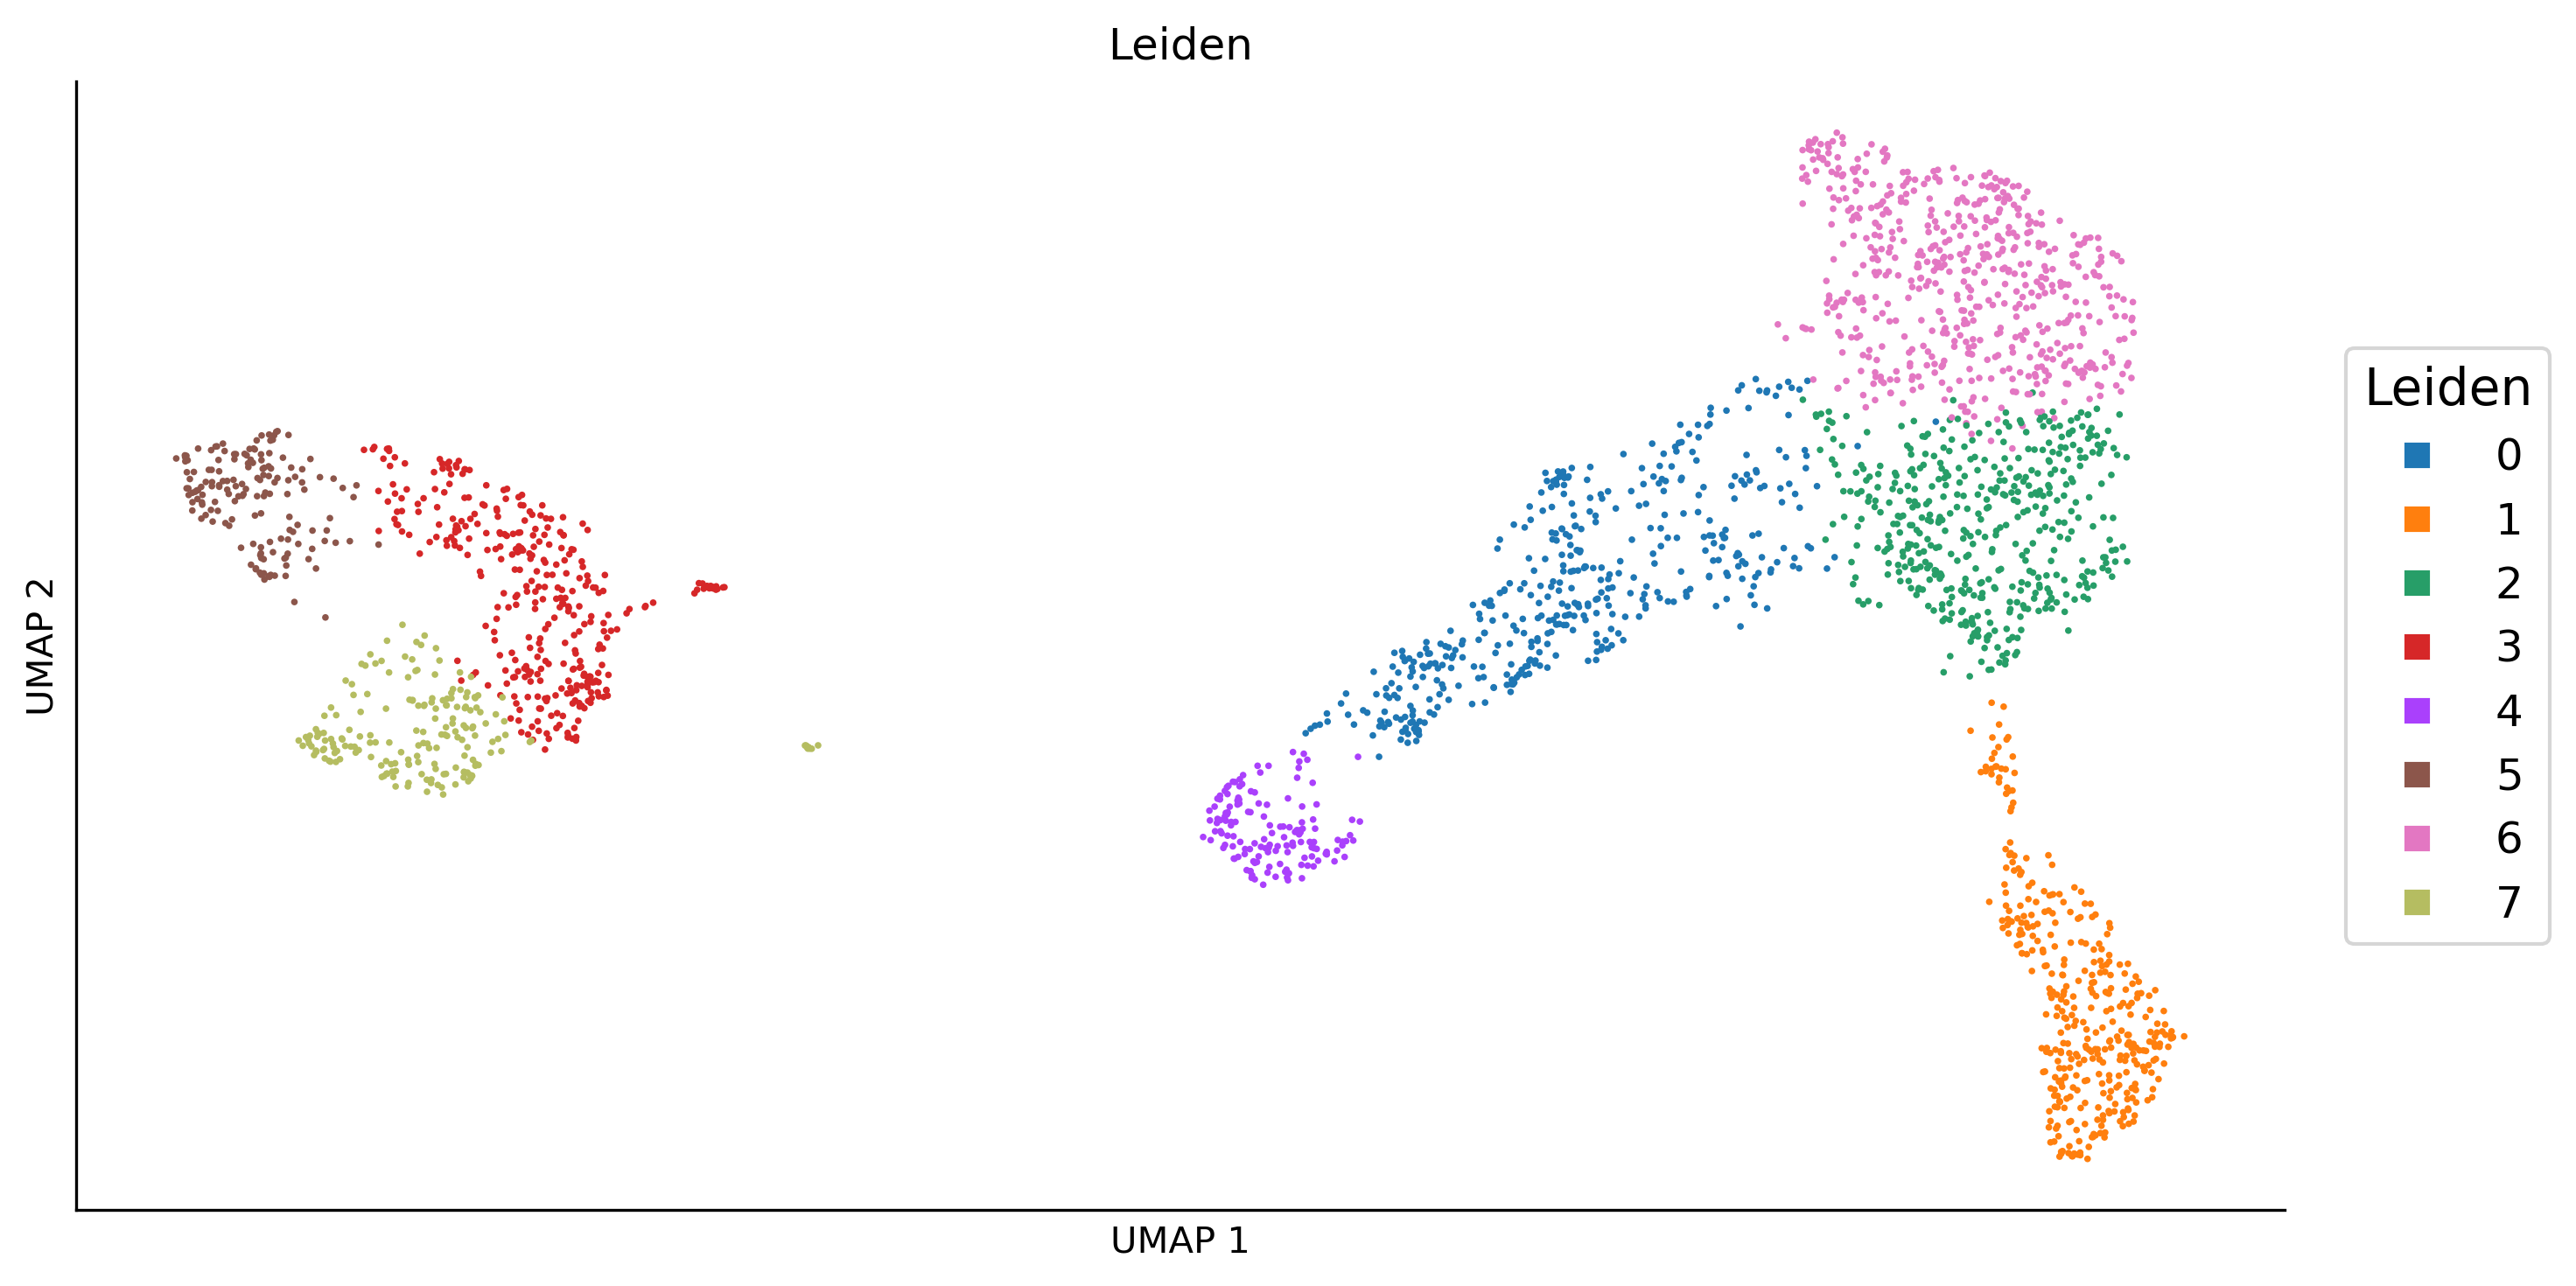

In [6]:
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2)
scv.umap(adata, "leiden", legend_loc="right");

### Custom categorical colors

`set_categorical_colors` writes Scanpy-style colors into `adata.uns[f"{feature}_colors"]`, which `scurvy` then reuses across plots.

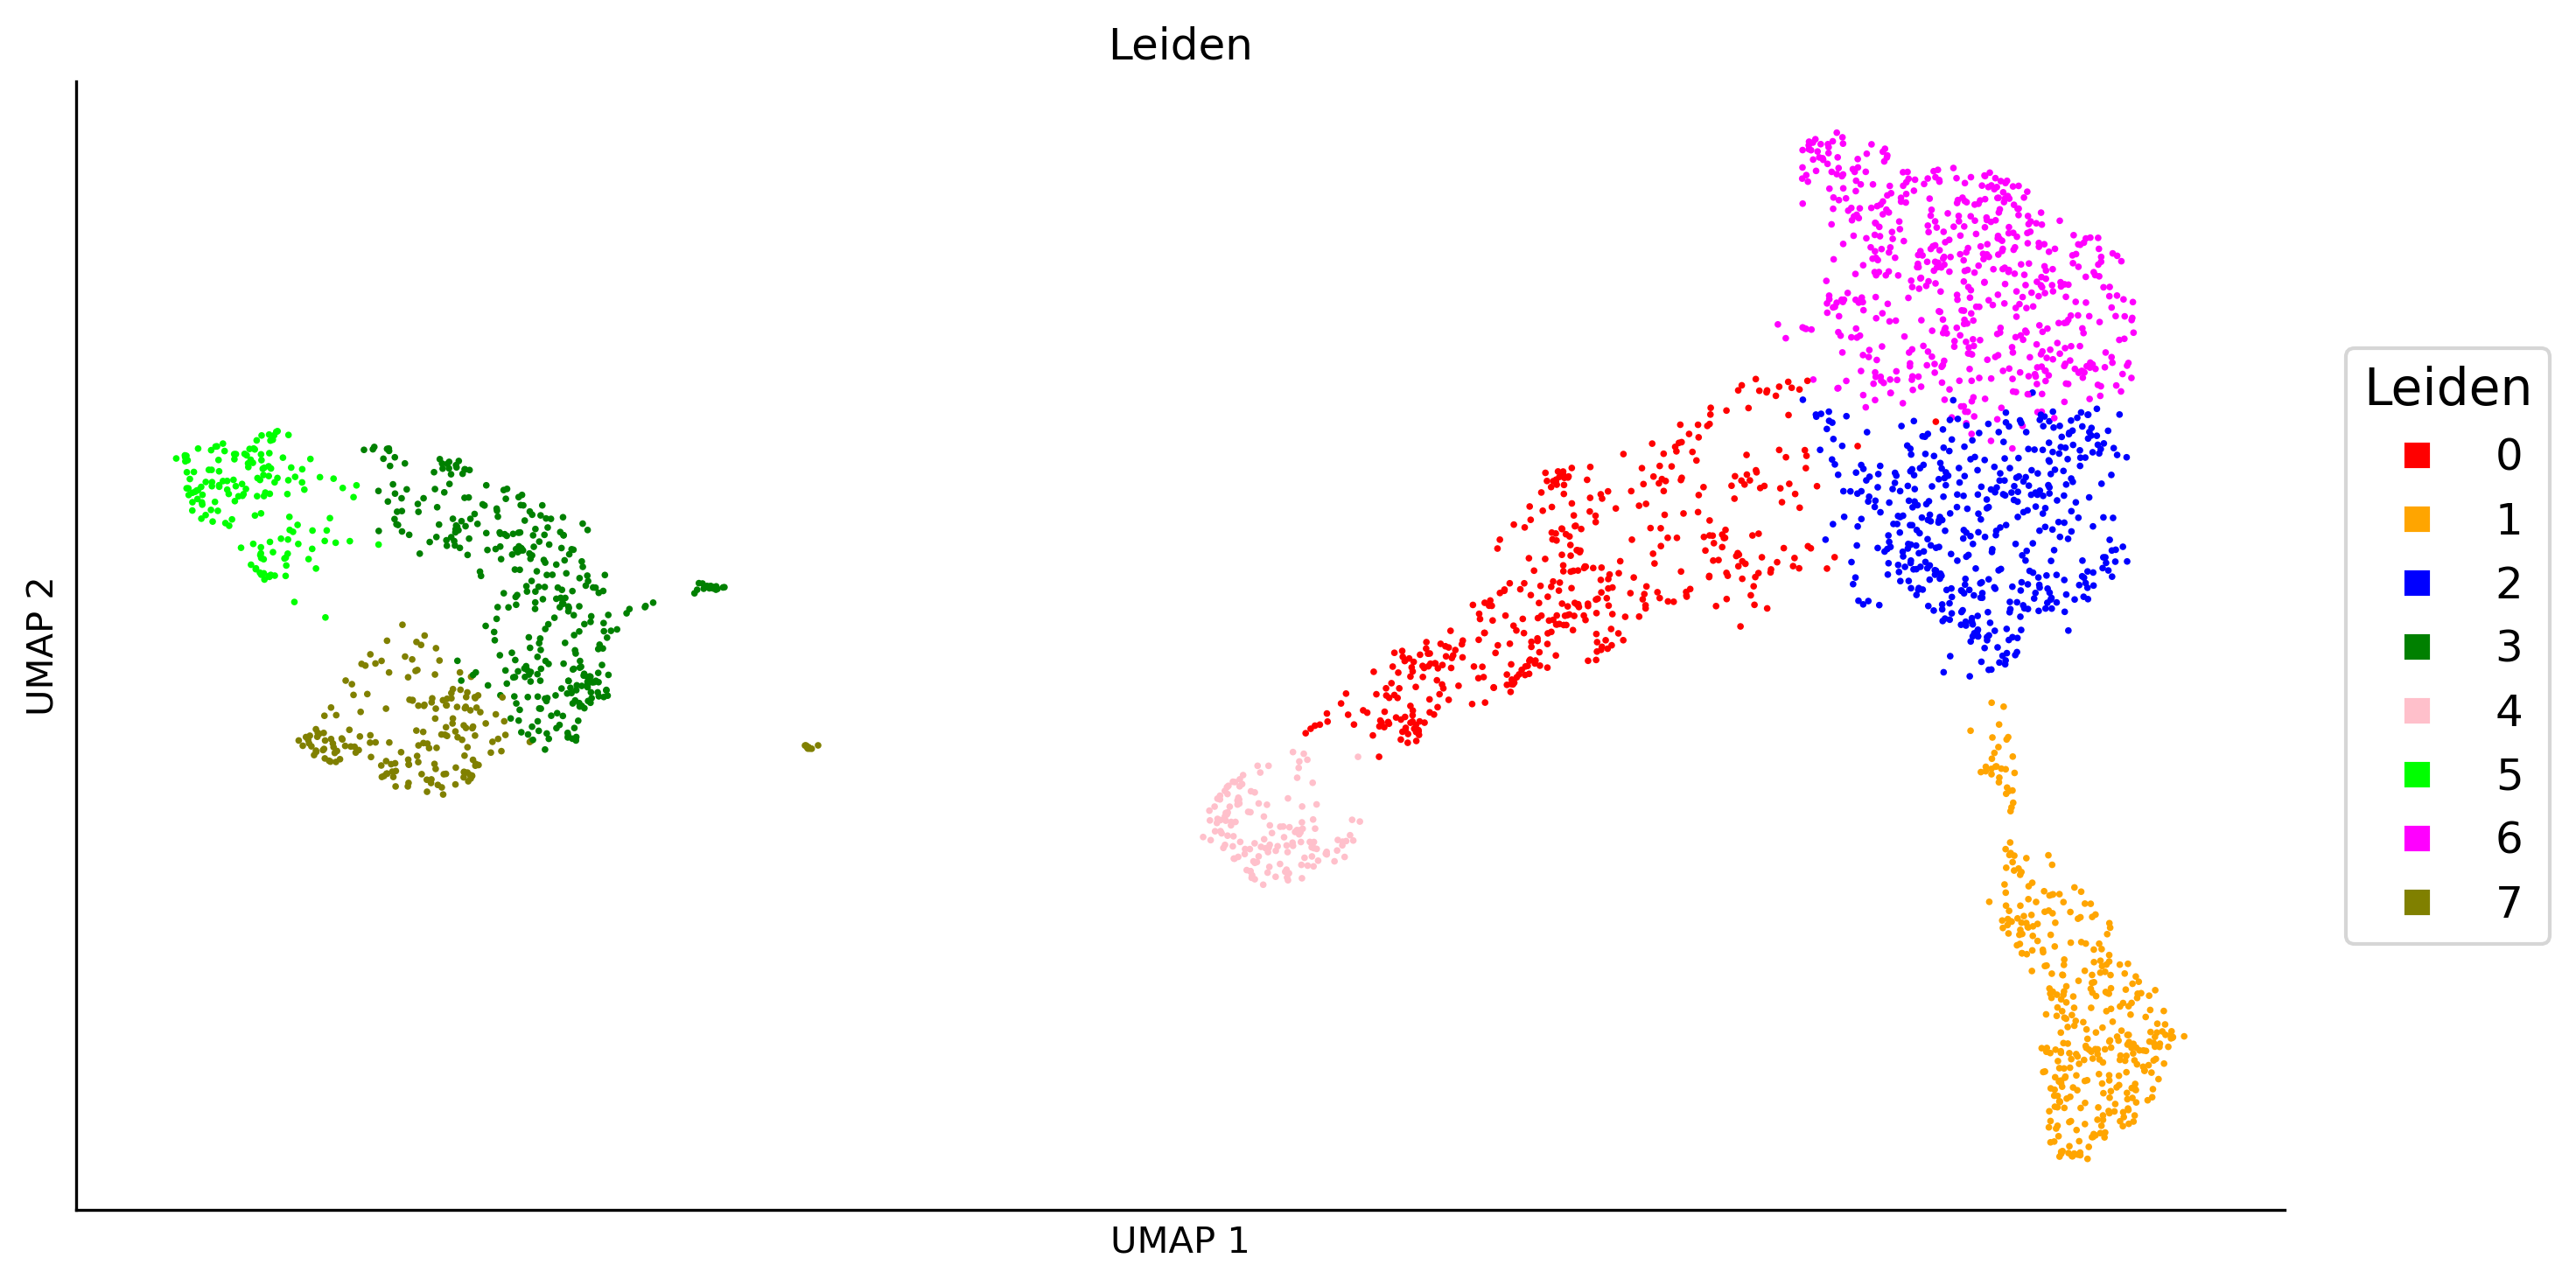

In [7]:
scv.set_categorical_colors(adata, "leiden", {
    "0": "red",
    "1": "orange",
    "2": "blue",
    "3": "green",
    "4": "pink",
    "5": "lime",
    "6": "magenta",
    "7": "olive",
})
scv.umap(adata, "leiden", legend_loc="right");

## Split UMAPs and composition plots

This section creates a simple synthetic sample label, then compares cluster structure between samples with split embeddings and bar charts.

In [ ]:
import numpy as np
adata.obs["sample"] = np.concatenate([
    np.zeros(len(adata.obs) // 2, int),
    np.ones(len(adata.obs) - len(adata.obs) // 2, int),
])
adata.obs["sample"] = adata.obs["sample"].map({0: "sample_0", 1: "sample_1"}).astype("category")
adata.obs["sample"]

AAACATACAACCAC-1    sample_0
AAACATTGAGCTAC-1    sample_0
AAACATTGATCAGC-1    sample_0
AAACCGTGCTTCCG-1    sample_0
AAACCGTGTATGCG-1    sample_0
                      ...   
TTTCGAACTCTCAT-1    sample_1
TTTCTACTGAGGCA-1    sample_1
TTTCTACTTCCTCG-1    sample_1
TTTGCATGAGAGGC-1    sample_1
TTTGCATGCCTCAC-1    sample_1
Name: sample, Length: 2700, dtype: category
Categories (2, object): ['sample_0', 'sample_1']

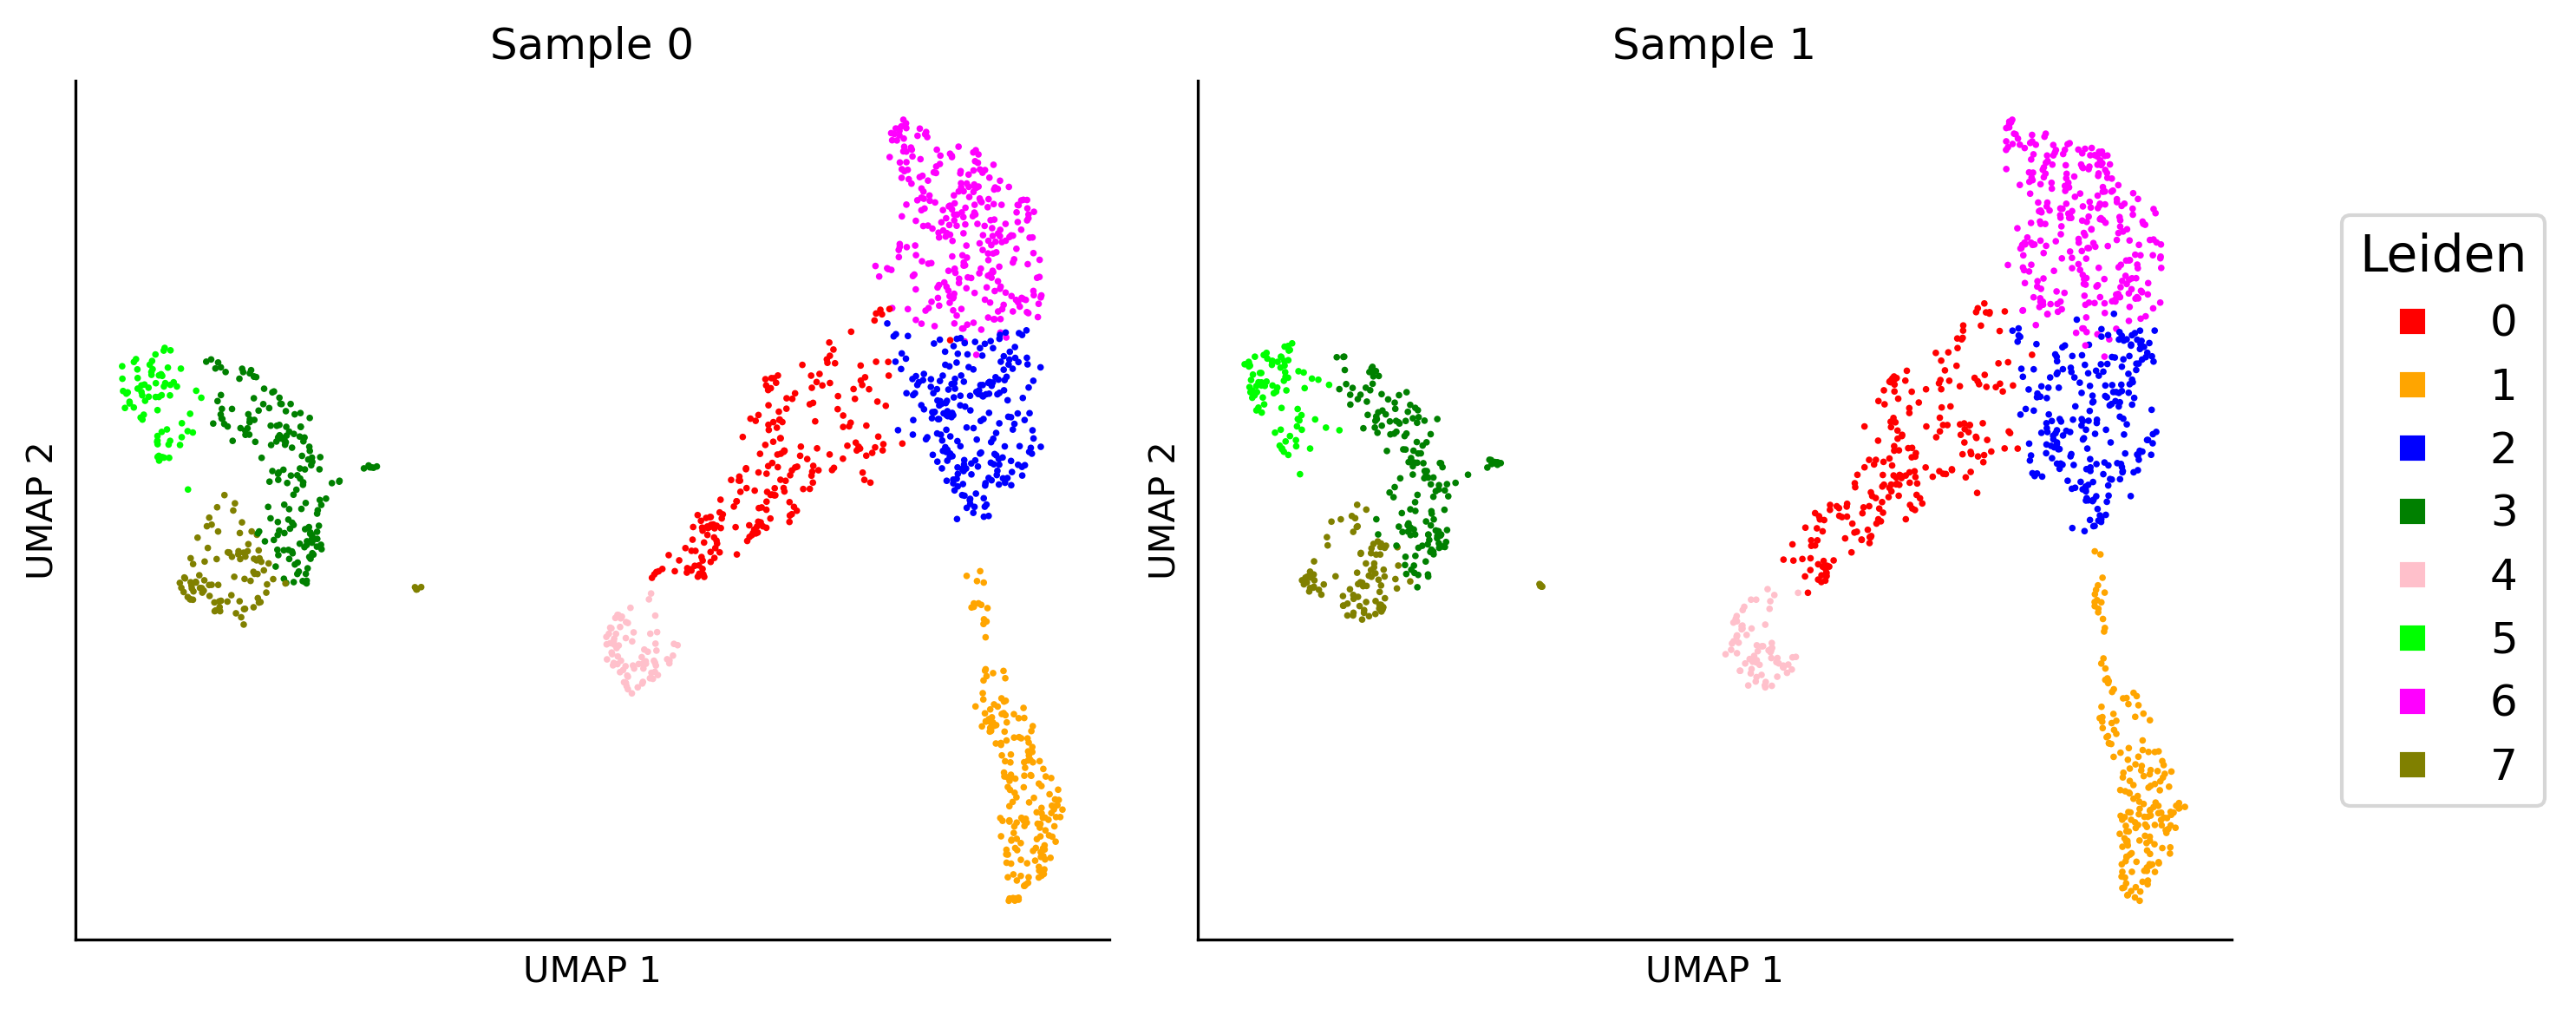

In [9]:
scv.umap_split(adata, "leiden", "sample", legend_loc="vertical", figsize=(10, 4));

### Counts and proportions

`graph_counts` works directly with the current defaults.

`graph_proportions` currently needs an explicit `percentages_color` in this example because the package default color value is not accepted by Matplotlib.

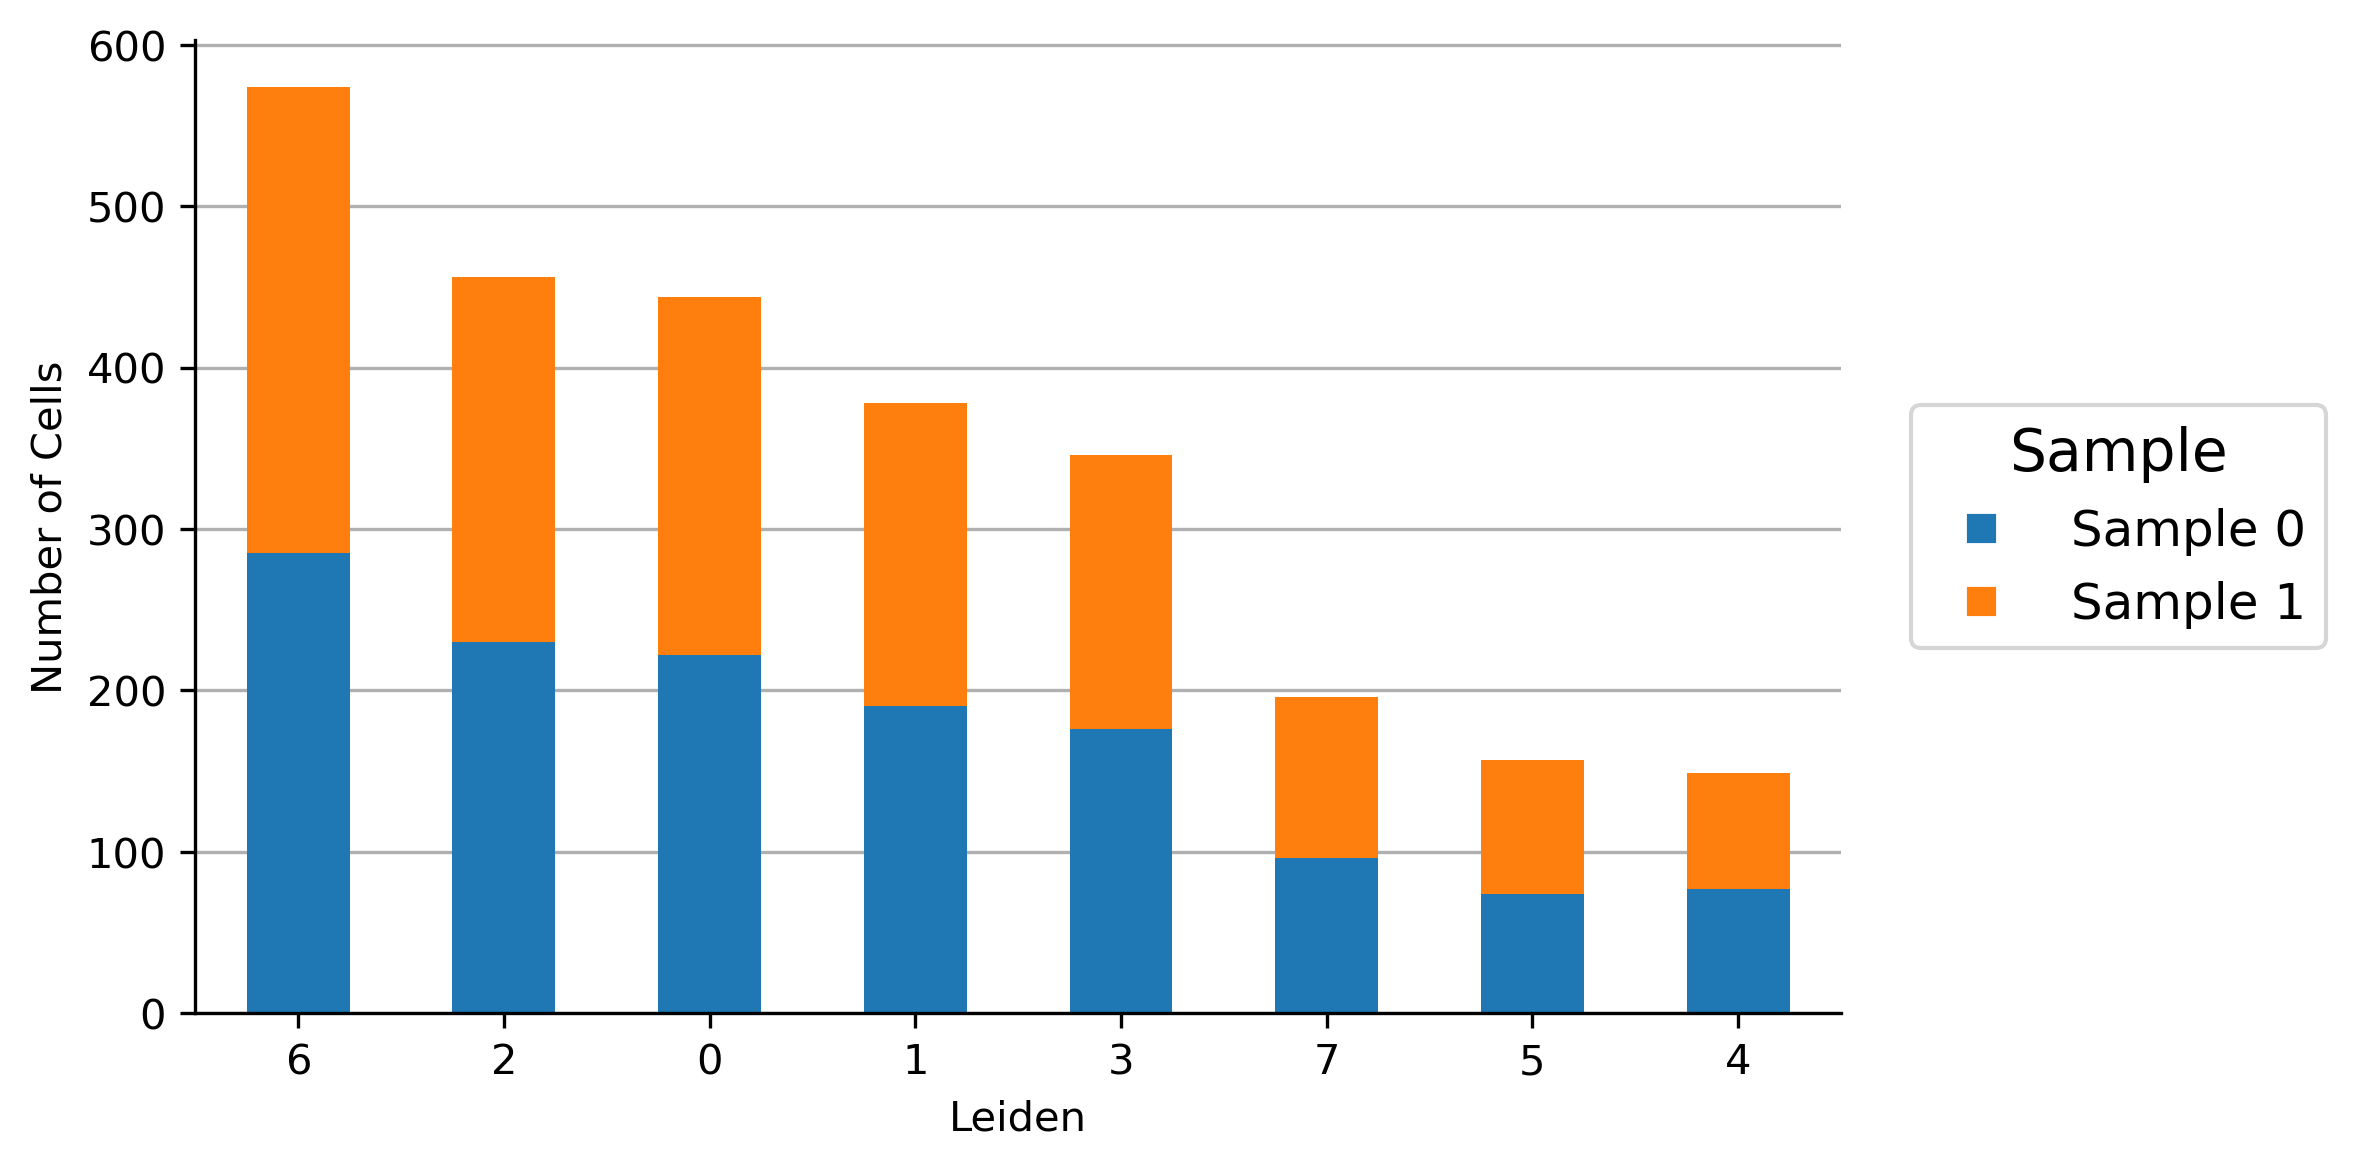

In [13]:
adata.obs["leiden_test"] = adata.obs["leiden"].map(lambda x: f"leiden_{x}")
scv.graph_counts(adata, "sample", "leiden", x_tick_rotation=0, stack=True);

ValueError: '#0000000' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

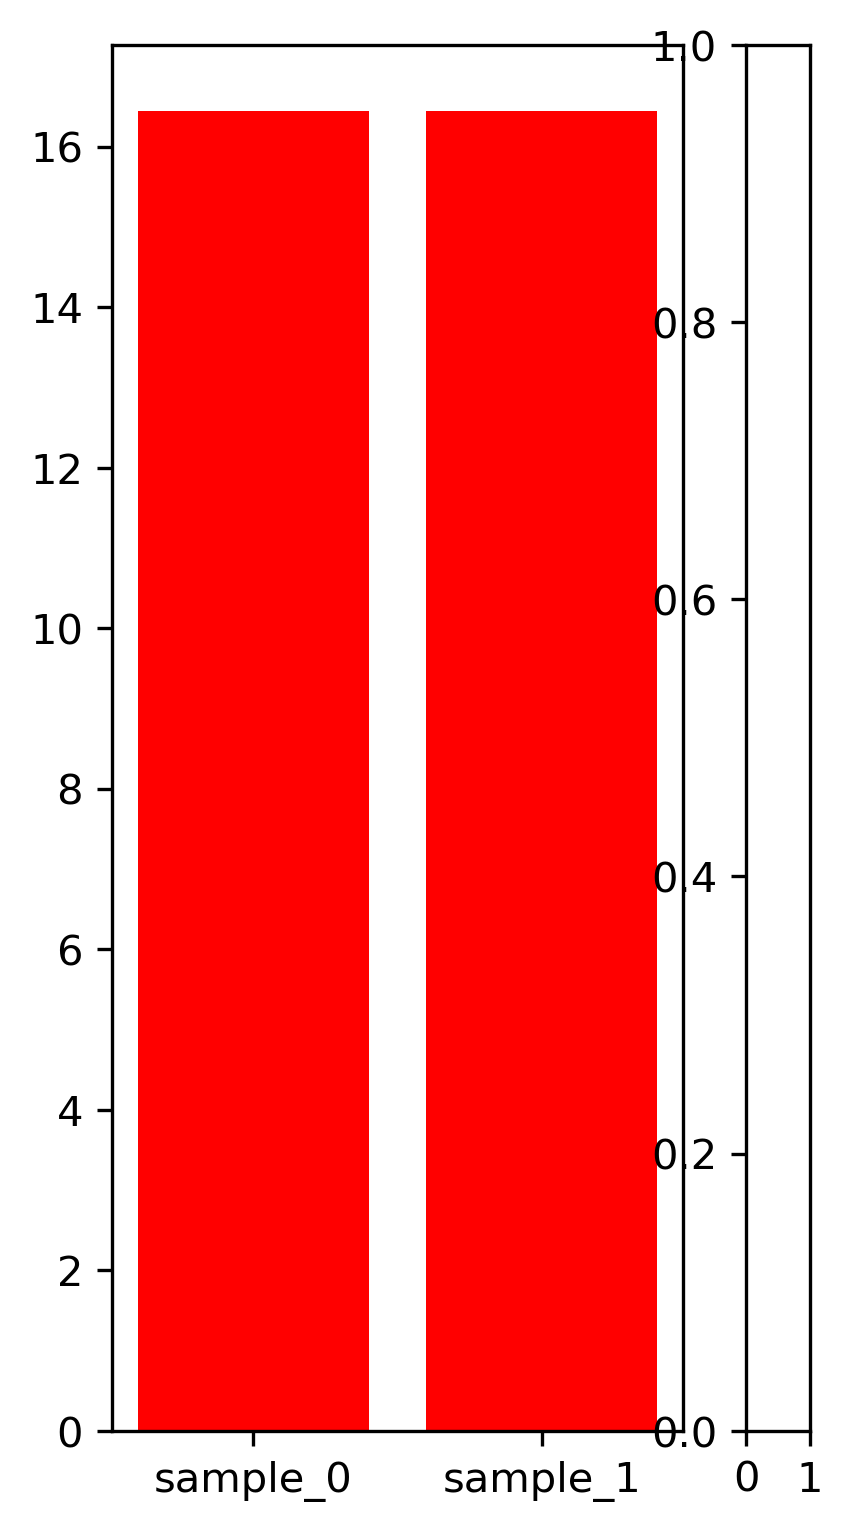

In [ ]:
scv.graph_proportions(
    adata,
    "sample",
    "leiden",
    figsize=(3, 6),
    percentages_color="#000000",
);